In [61]:
import pandas as pd
df = pd.read_csv("../datasets/exam_score_baseline.csv")

# Task 1: Define the Modeling Problem

Target variable (y): 
- Exam_Score

Predictors (X):
- Hours_Studied
- Attendance_Percent
- Sleep_Hours
- Assignments_Completed

Synthetic_Record_ID is excluded because it is only an identifier.

In [62]:
numeric_features = [
    "Hours_Studied",
    "Attendance_Percent",
    "Sleep_Hours",
    "Assignments_Completed"
]

X = df[numeric_features]
y = df["Exam_Score"]

df.head()

,Synthetic_Record_ID,Hours_Studied,Attendance_Percent,Sleep_Hours,Assignments_Completed,Exam_Score
0,S001,10.2,93,6.3,4,70
1,S002,11.3,100,7.3,9,77
2,S003,12.6,76,8.0,9,77
3,S004,5.3,84,6.4,7,65
4,S005,5.1,77,5.7,8,52


# Task 2: Predict the Effect of Scale

kNN finds the data points that are closest to each other.

Some predictors have much larger number ranges than others. In our dataset, Attendance_Percent has the largest range, so it could have more influence on the distance calculation just because its numbers are bigger.

Standardizing puts the predictors on a similar scale. This helps kNN compare the predictors more fairly and can change which data points are considered the nearest neighbors.

In [63]:
for feature in numeric_features:
    feature_range = df[feature].max() - df[feature].min()
    print(feature, "range:", feature_range)

Hours_Studied range: 18.0
Attendance_Percent range: 42
Sleep_Hours range: 4.699999999999999
Assignments_Completed range: 9


# Task 3: Prepare the Predictors

All four predictors in the Group 1 baseline dataset are numerical, so no categorical encoding is needed.

The predictors will stay in their original form for now. Scaling will be done later inside the kNN pipeline so that the scaler only uses the training data.

# Task 4: Compare Linear Regression and kNN

This task compares three models:

1. Ordinary Linear Regression
2. kNN with k=5 using the original predictor values
3. kNN with k=5 using standardized predictor values

The goal is to see whether scaling improves kNN performance and how kNN compares with the Linear Regression baseline.

In [84]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

## Build the Models

The unscaled kNN model uses the original predictor values.

The scaled kNN model uses a pipeline that standardizes the predictors first and then applies kNN.

In [65]:
linear_model = LinearRegression()

knn_unscaled = KNeighborsRegressor(
    n_neighbors=5
)

knn_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=5))
])

## Cross-Validation Setup

All three models are evaluated using the same repeated cross-validation procedure so the comparison is fair.

- 5 folds
- 5 repeats
- 25 total evaluation folds
- random_state = 407

In [66]:
from sklearn.model_selection import RepeatedKFold, cross_validate

cv = RepeatedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=407
)

In [67]:
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

In [68]:
results_linear = cross_validate(
    linear_model,
    X,
    y,
    cv=cv,
    scoring=scoring
)

results_knn_unscaled = cross_validate(
    knn_unscaled,
    X,
    y,
    cv=cv,
    scoring=scoring
)

results_knn_scaled = cross_validate(
    knn_scaled,
    X,
    y,
    cv=cv,
    scoring=scoring
)

## Evaluate the Models

Each model is tested using MAE, RMSE, and R².

- **MAE:** Average prediction error. Lower is better.
- **RMSE:** Similar to MAE, but larger mistakes count more. Lower is better.
- **R²:** Shows how much variation in Exam_Score is explained by the model. Higher is better.

In [69]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "kNN k=5 Unscaled",
        "kNN k=5 Scaled"
    ],
    "MAE Mean": [
        -results_linear["test_MAE"].mean(),
        -results_knn_unscaled["test_MAE"].mean(),
        -results_knn_scaled["test_MAE"].mean()
    ],
    "MAE SD": [
        results_linear["test_MAE"].std(),
        results_knn_unscaled["test_MAE"].std(),
        results_knn_scaled["test_MAE"].std()
    ],
    "RMSE Mean": [
        -results_linear["test_RMSE"].mean(),
        -results_knn_unscaled["test_RMSE"].mean(),
        -results_knn_scaled["test_RMSE"].mean()
    ],
    "RMSE SD": [
        results_linear["test_RMSE"].std(),
        results_knn_unscaled["test_RMSE"].std(),
        results_knn_scaled["test_RMSE"].std()
    ],
    "R2 Mean": [
        results_linear["test_R2"].mean(),
        results_knn_unscaled["test_R2"].mean(),
        results_knn_scaled["test_R2"].mean()
    ],
    "R2 SD": [
        results_linear["test_R2"].std(),
        results_knn_unscaled["test_R2"].std(),
        results_knn_scaled["test_R2"].std()
    ]
})

comparison.round(3)

,Model,MAE Mean,MAE SD,RMSE Mean,RMSE SD,R2 Mean,R2 SD
0,Linear Regression,3.084,0.459,3.766,0.507,0.753,0.065
1,kNN k=5 Unscaled,4.272,0.509,5.135,0.540,0.547,0.088
2,kNN k=5 Scaled,4.394,0.495,5.279,0.509,0.516,0.117


## Results

Linear Regression performed better than both kNN models.

The unscaled kNN model performed slightly better than the scaled kNN model in this comparison.

- Linear Regression had the lowest MAE and RMSE.
- Linear Regression also had the highest R².
- Scaling did not improve kNN performance for k=5 on this baseline dataset.

This shows that scaling can be important for kNN, but it does not guarantee that the scaled model will always perform better.

# Task 5: Choose the Best Number of Neighbors

In this task, scaled kNN will be tested using different values of k:

- k = 1
- k = 3
- k = 5
- k = 9
- k = 15

The goal is to see how changing the number of neighbors affects model performance.

The best k will be selected mainly by the lowest mean RMSE, while MAE, R², and variability will also be considered.

In [70]:
k_values = [1, 3, 5, 9, 15]

In [71]:
k_results = []

In [72]:
for k in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(
            n_neighbors=k,
            weights="uniform"
        ))
    ])

    results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring
    )

    k_results.append({
        "k": k,
        "MAE Mean": -results["test_MAE"].mean(),
        "MAE SD": results["test_MAE"].std(),
        "RMSE Mean": -results["test_RMSE"].mean(),
        "RMSE SD": results["test_RMSE"].std(),
        "R2 Mean": results["test_R2"].mean(),
        "R2 SD": results["test_R2"].std()
    })

In [73]:
k_table = pd.DataFrame(k_results)

k_table.round(3)

,k,MAE Mean,MAE SD,RMSE Mean,RMSE SD,R2 Mean,R2 SD
0,1,5.235,0.836,6.306,0.857,0.302,0.221
1,3,4.656,0.647,5.614,0.607,0.450,0.143
2,5,4.394,0.495,5.279,0.509,0.516,0.117
3,9,4.302,0.524,5.071,0.584,0.563,0.060
4,15,4.312,0.427,5.190,0.516,0.542,0.061


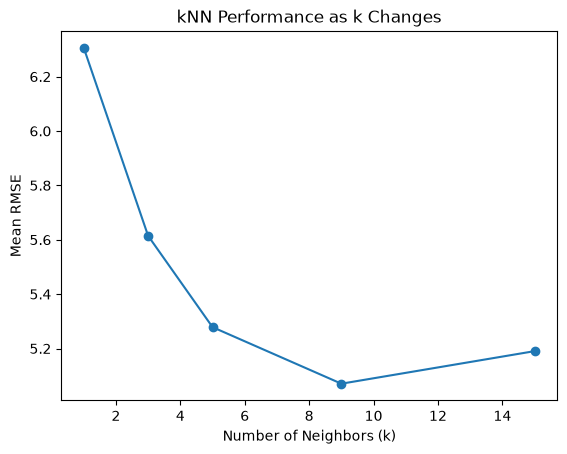

In [82]:
plt.plot(
    k_table["k"],
    k_table["RMSE Mean"],
    marker="o"
)

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Mean RMSE")
plt.title("kNN Performance as k Changes")

plt.show()

## Task 5 Results

The best value of k was 9 because it had the lowest mean RMSE of 5.071.

k=9 also had the lowest MAE and the highest R² among the tested values.

Model performance improved as k increased from 1 to 9, but performance became slightly worse at k=15. This suggests that using more neighbors helped reduce sensitivity to individual data points up to k=9, but using too many neighbors began to smooth the model too much.

# Task 6: Compare Neighbor Weighting

The selected value from Task 5 was k = 9.

In this task, two scaled kNN models will be compared:

1. Uniform weights
2. Distance weights

Uniform weights treat all 9 neighbors equally.

Distance weights give closer neighbors more influence on the prediction.

The goal is to see whether distance weighting improves model performance.

In [74]:
knn_uniform_9 = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(
        n_neighbors=9,
        weights = "uniform"
    ))
])

knn_distance_9 = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(
        n_neighbors=9,
        weights="distance"
    ))
])

In [75]:
uniform_results = cross_validate(
    knn_uniform_9,
    X,
    y,
    cv=cv,
    scoring=scoring
)

distance_results = cross_validate(
    knn_distance_9,
    X,
    y,
    cv=cv,
    scoring=scoring
)

In [76]:
weight_table = pd.DataFrame({
    "Weights": [
        "Uniform",
        "Distance"
    ],
    "MAE Mean": [
        -uniform_results["test_MAE"].mean(),
        -distance_results["test_MAE"].mean()
    ],
    "MAE SD": [
        uniform_results["test_MAE"].std(),
        distance_results["test_MAE"].std()
    ],
    "RMSE Mean": [
        -uniform_results["test_RMSE"].mean(),
        -distance_results["test_RMSE"].mean()
    ],
    "RMSE SD": [
        uniform_results["test_RMSE"].std(),
        distance_results["test_RMSE"].std()
    ],
    "R2 Mean": [
        uniform_results["test_R2"].mean(),
        distance_results["test_R2"].mean()
    ],
    "R2 SD": [
        uniform_results["test_R2"].std(),
        distance_results["test_R2"].std()
    ]
})

weight_table.round(3)

,Weights,MAE Mean,MAE SD,RMSE Mean,RMSE SD,R2 Mean,R2 SD
0,Uniform,4.302,0.524,5.071,0.584,0.563,0.060
1,Distance,4.237,0.523,5.015,0.548,0.571,0.067


## Task 6 Results

Distance weighting performed slightly better than uniform weighting.

The distance-weighted model had a lower MAE and RMSE and a slightly higher R².

This suggests that giving closer neighbors more influence improved model performance a little for k=9.

# Task 7: Compare Selected kNN with Linear Regression

The selected kNN model uses:

- k = 9
- distance weighting
- standardized predictors

This task compares the selected kNN model with Linear Regression using cross-validated predictions.

A predicted-vs-actual plot will be used to see how closely each model's predictions match the actual Exam_Score values.

In [77]:
from sklearn.model_selection import KFold, cross_val_predict

In [78]:
plot_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=407
)

In [79]:
linear_predictions = cross_val_predict(
    linear_model,
    X,
    y,
    cv=plot_cv
)

knn_predictions = cross_val_predict(
    knn_distance_9,
    X,
    y,
    cv=plot_cv
)

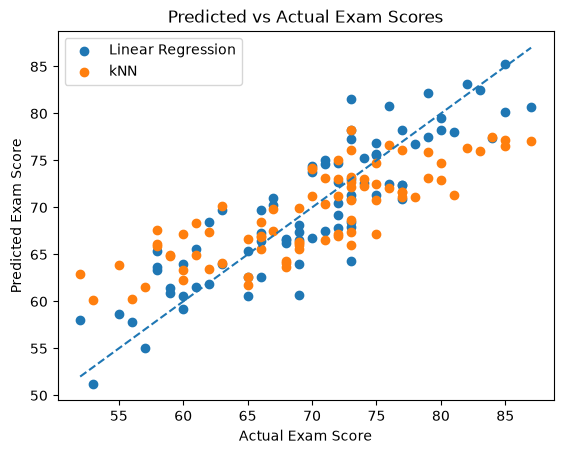

In [80]:
plt.scatter(y, linear_predictions, label="Linear Regression")
plt.scatter(y, knn_predictions, label="kNN")

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    linestyle="--"
)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Predicted vs Actual Exam Scores")
plt.legend()

plt.show()

## Task 7 Results

The predicted-vs-actual plot shows that Linear Regression generally follows the perfect prediction line more closely than the selected kNN model.

The kNN predictions are more concentrated around the middle range of Exam_Score. It tends to predict some lower scores too high and some higher scores too low.

This agrees with the cross-validation results, where Linear Regression had lower MAE and RMSE and a higher R² than kNN.

For Group 1's clean baseline data, Linear Regression performed better than scaled kNN. kNN performance improved as k increased from 1 to 9, but became slightly worse at k=15.

A limitation is that this dataset is small and synthetic, so the results may not represent real student data. These relationships are predictive and should not be interpreted as causal.

## Model Recommendation

For this clean baseline dataset, Linear Regression is recommended because it had lower MAE and RMSE and a higher R² than the selected kNN model.

The best kNN model used k=9 with distance weighting, but it still did not outperform Linear Regression.

# Final Reflection

For Group 1's clean baseline dataset, Linear Regression performed better than scaled kNN.

The selected scaled kNN model used k=9 with distance weighting. kNN performance improved as k increased from 1 to 9, but became slightly worse at k=15.

This suggests that increasing k helped reduce sensitivity to individual neighbors up to a point, but using too many neighbors began to make the model less effective.

A limitation of this analysis is that the dataset is small and synthetic, so the results may not represent real student data.

The relationships found by these models are predictive and should not be interpreted as causal.